In [1]:
import torch
import models as m
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
import math

In [2]:
torch.set_default_dtype(torch.float32)

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

def t(x):
    return torch.as_tensor(x, dtype=torch.get_default_dtype(), device=device)

Using device: cuda:0


In [3]:
BASE_PATH = os.getcwd()
RUNS_ROOT = os.path.join(BASE_PATH, "runs")

EXP_NAME = "comparaison"   
RUN_ID = "008"                  

EXP_DIR = os.path.join(RUNS_ROOT, EXP_NAME)
RUN_DIR = os.path.join(EXP_DIR, RUN_ID)
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
LOGS_DIR = os.path.join(RUN_DIR, "logs")
SAMPLES_DIR = os.path.join(RUN_DIR, "samples_pc")
os.makedirs(SAMPLES_DIR, exist_ok=True)

with open(os.path.join(LOGS_DIR, "hparams.json"), "r") as f:
    hparams = json.load(f)

print("Loaded hparams from:", RUN_DIR)
print("sigma hyperparams:", hparams["sigma"])
print("img_size:", hparams["img_size"])

sigma_min = hparams["sigma"]["min"]
sigma_max = hparams["sigma"]["max"]

img_size = hparams["img_size"]
C = hparams["model"]["in_channel"]
H = W = img_size

Loaded hparams from: /home/infres/rplanchon-23/code/DSM/src/VE-SDE/celebA/runs/comparaison/008
sigma hyperparams: {'min': 0.01, 'max': 40.0}
img_size: 64


src/VE-SDE/celebA/runs/comparaison/004/weights/model_epoch056_step355000.pt  meilleur pour l'instant \\
src/VE-SDE/celebA/runs/comparaison/004/weights/model_epoch035_step226000.pt  mauvais \\
src/VE-SDE/celebA/runs/comparaison/004/weights/model_epoch056_step360000.pt  ok \\
src/VE-SDE/celebA/runs/comparaison/004/weights/model_epoch058_step368000.pt très mauvais \\
src/VE-SDE/celebA/runs/comparaison/004/weights/model_epoch055_step351000.pt null \\
src/VE-SDE/celebA/runs/comparaison/004/weights/model_epoch056_step358000.pt


In [4]:
state_dict = torch.load(
    os.path.join(WEIGHTS_DIR, "model_ema.pt"),
    map_location=device,
    weights_only=True,
)

model = m.SmallUNetSigma(
    in_ch=hparams["model"]["in_channel"],
    base_ch=hparams["model"]["base_ch"],
    channel_mults=hparams["model"]["channel_mults"],
    emb_dim=hparams["model"]["sigma_emb_dim"],
).to(device)

model.load_state_dict(state_dict)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model has {total_params/1e6:.2f}M parameters")

Model has 48.45M parameters


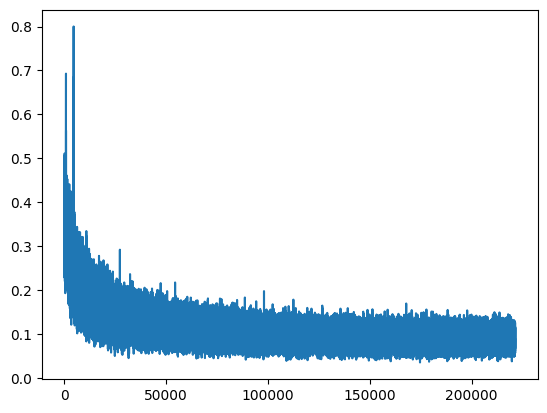

In [5]:
Loss = np.load(os.path.join(LOGS_DIR,'train_loss.npy'))
steps_eval = np.load(os.path.join(LOGS_DIR,'steps_eval.npy'))
plt.plot(Loss[200:])
plt.show()


In [6]:
# VE schedule σ(t) and g(t)
# Training: log σ(t) = log σ_min + t (log σ_max - log σ_min), t ∈ [0,1]

log_sigma_min = t(sigma_min).log()
log_sigma_max = t(sigma_max).log()
log_r = log_sigma_max - log_sigma_min   # log(σ_max / σ_min)

def sigma_of_t(t_scalar):
    """
    t_scalar: scalaire ou tensor in [0,1]
    returns σ(t) avec même dtype/device.
    """
    return torch.exp(log_sigma_min + t_scalar * log_r)

def g_of_t(t_scalar):
    """
    g(t) = sqrt(d/dt σ^2(t))
         = sqrt(2 log(σ_max/σ_min)) * σ(t)
    car σ^2(t) = σ_min^2 * (σ_max/σ_min)^{2t}.
    """
    sigma_t = sigma_of_t(t_scalar)
    return torch.sqrt(2.0 * log_r) * sigma_t

# Sanity check
for val in [0.0, 0.5, 1.0]:
    s = sigma_of_t(t(val))
    g = g_of_t(t(val))
    print(f"t={val:.2f} -> sigma={s.item():.4f}, g={g.item():.4f}")

t=0.00 -> sigma=0.0100, g=0.0407
t=0.50 -> sigma=0.6325, g=2.5759
t=1.00 -> sigma=40.0000, g=162.9140


In [7]:
def minmax_renorm_to_minus1_1(x):
    """
    x: (B, C, H, W)
    Renormalise chaque image individuellement dans [-1,1]
    via (x - min) / (max - min) * 2 - 1
    où min/max sont pris sur (C,H,W) pour chaque image.
    """
    B = x.shape[0]
    x_flat = x.view(B, -1)                  # (B, C*H*W)
    x_min = x_flat.min(dim=1).values.view(B, 1, 1, 1)
    x_max = x_flat.max(dim=1).values.view(B, 1, 1, 1)

    # éviter la division par 0
    denom = (x_max - x_min).clamp_min(1e-8)

    x_scaled = (x - x_min) / denom          # dans [0,1]
    x_scaled = x_scaled * 2.0 - 1.0         # dans [-1,1]
    return x_scaled


 

In [8]:
def per_image_minmax_to_01(x):
    """
    x : (B, C, H, W)
    Pour chaque image du batch, fait :
        x -> (x - min) / (max - min)  dans [0,1]
    avec min/max pris sur (C,H,W) de chaque image séparément.
    """
    B = x.shape[0]
    x_flat = x.view(B, -1)                        # (B, C*H*W)
    x_min = x_flat.min(dim=1).values.view(B, 1, 1, 1)
    x_max = x_flat.max(dim=1).values.view(B, 1, 1, 1)
    denom = (x_max - x_min).clamp_min(1e-8)
    x_01 = (x - x_min) / denom
    return x_01


#### PC SAMPLER VE classique

#### PC SAMPLER VE SDE SNR 

In [9]:
# --------- VE SDE de base (forward) ---------
class VESDE:
    def __init__(self, sigma_min=0.01, sigma_max=50.0, N=1000):
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.N = N
        self._log_ratio = math.log(self.sigma_max) - math.log(self.sigma_min)

    def sigma(self, t):
        # t \in [0,1]
        return self.sigma_min * (self.sigma_max / self.sigma_min) ** t

    def g(self, t):
        # diffusion coeff g(t) s.t. dx = g(t) dW
        return torch.sqrt(torch.tensor(2.0 * self._log_ratio, device=t.device)) * self.sigma(t)

    def marginal_prob(self, x0, t):
        std = self.sigma(t)
        mean = x0
        return mean, std

    def prior_sampling(self, shape, device):
        # p(x_T) ~ N(0, sigma_max^2 I)
        return torch.randn(*shape, device=device) * self.sigma_max

sde = VESDE(sigma_min=sigma_min, sigma_max=sigma_max, N=1000)

# --------- Correcteur Langevin avec SNR (Song) ---------
def langevin_corrector_snr(x, t_vec, score_model, snr=0.16, n_steps=1,
                           sigma_cutoff=sigma_max,        # pas de correcteur si sigma trop grand
                           max_step_scale=np.inf):     # clamp sur la taille de pas relative à sigma^2
    """
    x      : (B,C,H,W)
    t_vec  : (B,) times in [0,1]
    snr    : SNR cible
    """

    B = x.shape[0]

    for _ in range(n_steps):
        # sigma(t) par échantillon
        sigma_vec = sde.sigma(t_vec)              # (B,)
        sigma_batch = sigma_vec.view(B, 1)        # (B,1) pour le modèle

        # 1) éventuellement on masque les gros sigmas
        #    (ici on ne corrige que sigma <= sigma_cutoff)
        mask = (sigma_vec <= sigma_cutoff)        # (B,)
        if not mask.any():
            # rien à corriger à ce t
            return x

        x_sub   = x[mask]
        sig_sub = sigma_batch[mask]

        grad  = score_model(x_sub, sig_sub)       # score(x, sigma(t))
        noise = torch.randn_like(x_sub)

        grad_norm  = torch.norm(grad.view(grad.shape[0], -1), dim=-1).mean()
        noise_norm = torch.norm(noise.view(noise.shape[0], -1), dim=-1).mean()

        # 2) step_size SNR, puis clamp
        raw_step = 2.0 * (snr * noise_norm / (grad_norm + 1e-12))**2

        # on scale le max par sigma^2 moyen sur ce sous-batch
        sigma2_mean = (sig_sub.squeeze(1)**2).mean()   # scalaire
        max_step = max_step_scale * sigma2_mean        # ex: 0.5 * sigma^2
        
        step_size = torch.clamp(raw_step, max=max_step)
        step_size_t = step_size.view(1, 1, 1, 1)
        # if np.random.random() < 0.05 : 
        #     print(raw_step,step_size)
        # 3) update
        x_mean_sub = x_sub + step_size_t * grad
        x_sub = x_mean_sub + torch.sqrt(2.0 * step_size_t) * noise

        # on remet à jour x uniquement sur mask
        x = x.clone()
        x[mask] = x_sub
    return x



def pc_sampler_ve_snr(
    num_samples=8,
    num_steps=1000,
    n_corrector_steps=1,
    snr=0.16,
    eps=1e-5,
    snapshots_every=50
):
    model.eval()
    B = num_samples

    with torch.no_grad():
        C = 3
        H = W = img_size
        x = sde.prior_sampling((B, C, H, W), device=device)

        snapshots = {}
        t_grid = torch.linspace(1.0, eps, num_steps + 1, device=device)

        for i in range(num_steps):
            t      = t_grid[i].expand(B)          # temps courant
            t_next = t_grid[i + 1].expand(B)      # temps suivant (plus petit)
            dt = (t_next[0] - t[0]).item()        # < 0

            # -------- 1) Predictor : reverse VE SDE de t -> t_next --------
            g_t   = sde.g(t)                      # (B,)
            
            sigma_vec   = sde.sigma(t)            # (B,)
            sigma_batch = sigma_vec.view(B, 1)    # (B,1)
            score = model(x, sigma_batch)         # score(x, sigma(t))                 # (B,C,H,W)

            drift = -(g_t ** 2).view(B, 1, 1, 1) * score
            noise = torch.randn_like(x)

            x_mean = x + drift * dt
            x = x_mean + noise * torch.sqrt(torch.tensor(-dt, device=device)) \
                        * g_t.view(B, 1, 1, 1)

            # -------- 2) Corrector : Langevin SNR à t_next --------
            
            x = langevin_corrector_snr(
                x, t_next, model,
                snr=snr,
                n_steps=n_corrector_steps
            )

            if (i % snapshots_every) == 0 or i == num_steps - 1:
                snapshots[i] = x.detach().cpu()

        return x, snapshots



##### TEST hyperparamètres

In [10]:
x_final_list = []
config_list = []

snr_list = [0.16]
num_steps_list = [1000]        
n_corrector_steps_list = [1]           

num_samples = 16

for snr in snr_list:
    for num_steps in num_steps_list:
        for n_corrector_steps in n_corrector_steps_list:
            x_final, _ = pc_sampler_ve_snr(
                num_samples=num_samples,
                num_steps=num_steps,
                n_corrector_steps=n_corrector_steps,
                snr=snr,
            )
            x_final_list.append(x_final)
            config_list.append((snr, num_steps, n_corrector_steps))


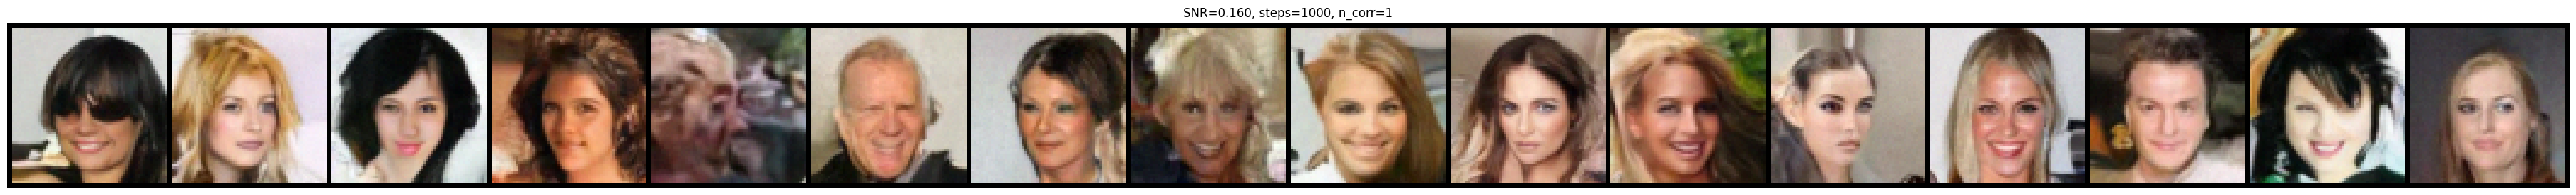

In [11]:
for (snr, num_steps, n_corrector_steps), x_final in zip(config_list, x_final_list):
    x_final_vis = per_image_minmax_to_01(x_final)
    grid = make_grid(x_final_vis, nrow=num_samples)
    plt.figure(figsize=(3 * num_samples, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.title(f"SNR={snr:.3f}, steps={num_steps}, n_corr={n_corrector_steps}")
    plt.show()


In [12]:
@torch.no_grad()
def pc_sampler_ve_snr_traj(
    num_samples=64,
    num_steps=1000,
    n_corrector_steps=1,
    snr=0.16,
    eps=1e-5,
    n_levels=12,          # nombre de niveaux de bruit / snapshots
):
    model.eval()
    B = num_samples

    C = 3
    H = W = img_size
    x = sde.prior_sampling((B, C, H, W), device=device)

    # grille de temps de 1 -> eps
    t_grid = torch.linspace(1.0, eps, num_steps + 1, device=device)

    # indices de steps où on veut un snapshot (inclut 0 et num_steps)
    # step_id = 0 : état initial, step_id = num_steps : état final
    level_ids = torch.linspace(0, num_steps, n_levels, dtype=torch.long).tolist()

    snapshots = {}
    snapshots[0] = x.detach().cpu()   # avant toute update

    for i in range(num_steps):
        t      = t_grid[i].expand(B)
        t_next = t_grid[i + 1].expand(B)
        dt = (t_next[0] - t[0]).item()   # < 0

        # 1) Predictor : reverse VE SDE de t -> t_next
        g_t = sde.g(t)                   # (B,)
        sigma_vec   = sde.sigma(t)       # (B,)
        sigma_batch = sigma_vec.view(B, 1)
        score = model(x, sigma_batch)    # score(x, sigma(t))

        drift = -(g_t ** 2).view(B, 1, 1, 1) * score
        noise = torch.randn_like(x)

        x_mean = x + drift * dt
        x = x_mean + noise * torch.sqrt(torch.tensor(-dt, device=device)) \
                    * g_t.view(B, 1, 1, 1)

        # 2) Corrector : Langevin SNR à t_next
        x = langevin_corrector_snr(
            x, t_next, model,
            snr=snr,
            n_steps=n_corrector_steps
        )

        step_id = i + 1  # steps 1..num_steps
        if step_id in level_ids:
            snapshots[step_id] = x.detach().cpu()

    return x, snapshots


In [13]:
def plot_pc_snr_evolution(snapshots, n_display=[], figsize_base=3.0):
    """
    snapshots : dict {step_id: (B,C,H,W)}
    n_display : nombre d'images différentes (lignes) à afficher
    """
 
    # steps triés
    step_ids = sorted(snapshots.keys())
    n_levels = len(step_ids)

    # on ne prend que les n_display premières images du batch
    B = snapshots[step_ids[0]].shape[0]
    
    if len(n_display) == 0 : 
        n_display = [i for i in range(B)]
    print(n_display,len(n_display))

    plt.figure(figsize=(figsize_base * n_levels, figsize_base * len(n_display)))

    for i,row in enumerate(n_display):
        for col, step_id in enumerate(step_ids):
            x_snap = snapshots[step_id]              # (B,C,H,W) sur CPU
            x_img = x_snap[row:row+1]                # (1,C,H,W)
            x_vis = per_image_minmax_to_01(x_img)[0] # (C,H,W)

            ax = plt.subplot(len(n_display), n_levels, i * n_levels + col + 1)
            ax.imshow(x_vis.permute(1, 2, 0).numpy())
            ax.axis("off")
            if i == 0:
                ax.set_title(f"step {step_id}")

    plt.tight_layout()
    plt.show()


In [14]:
num_samples = 64
num_steps = 1000
n_corrector_steps = 1
snr = 0.16

# par ex. 7 niveaux: init, 5 intermédiaires, final
x_final, snapshots = pc_sampler_ve_snr_traj(
    num_samples=num_samples,
    num_steps=num_steps,
    n_corrector_steps=n_corrector_steps,
    snr=snr,
    eps=1e-5,
    n_levels=12,
)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 12


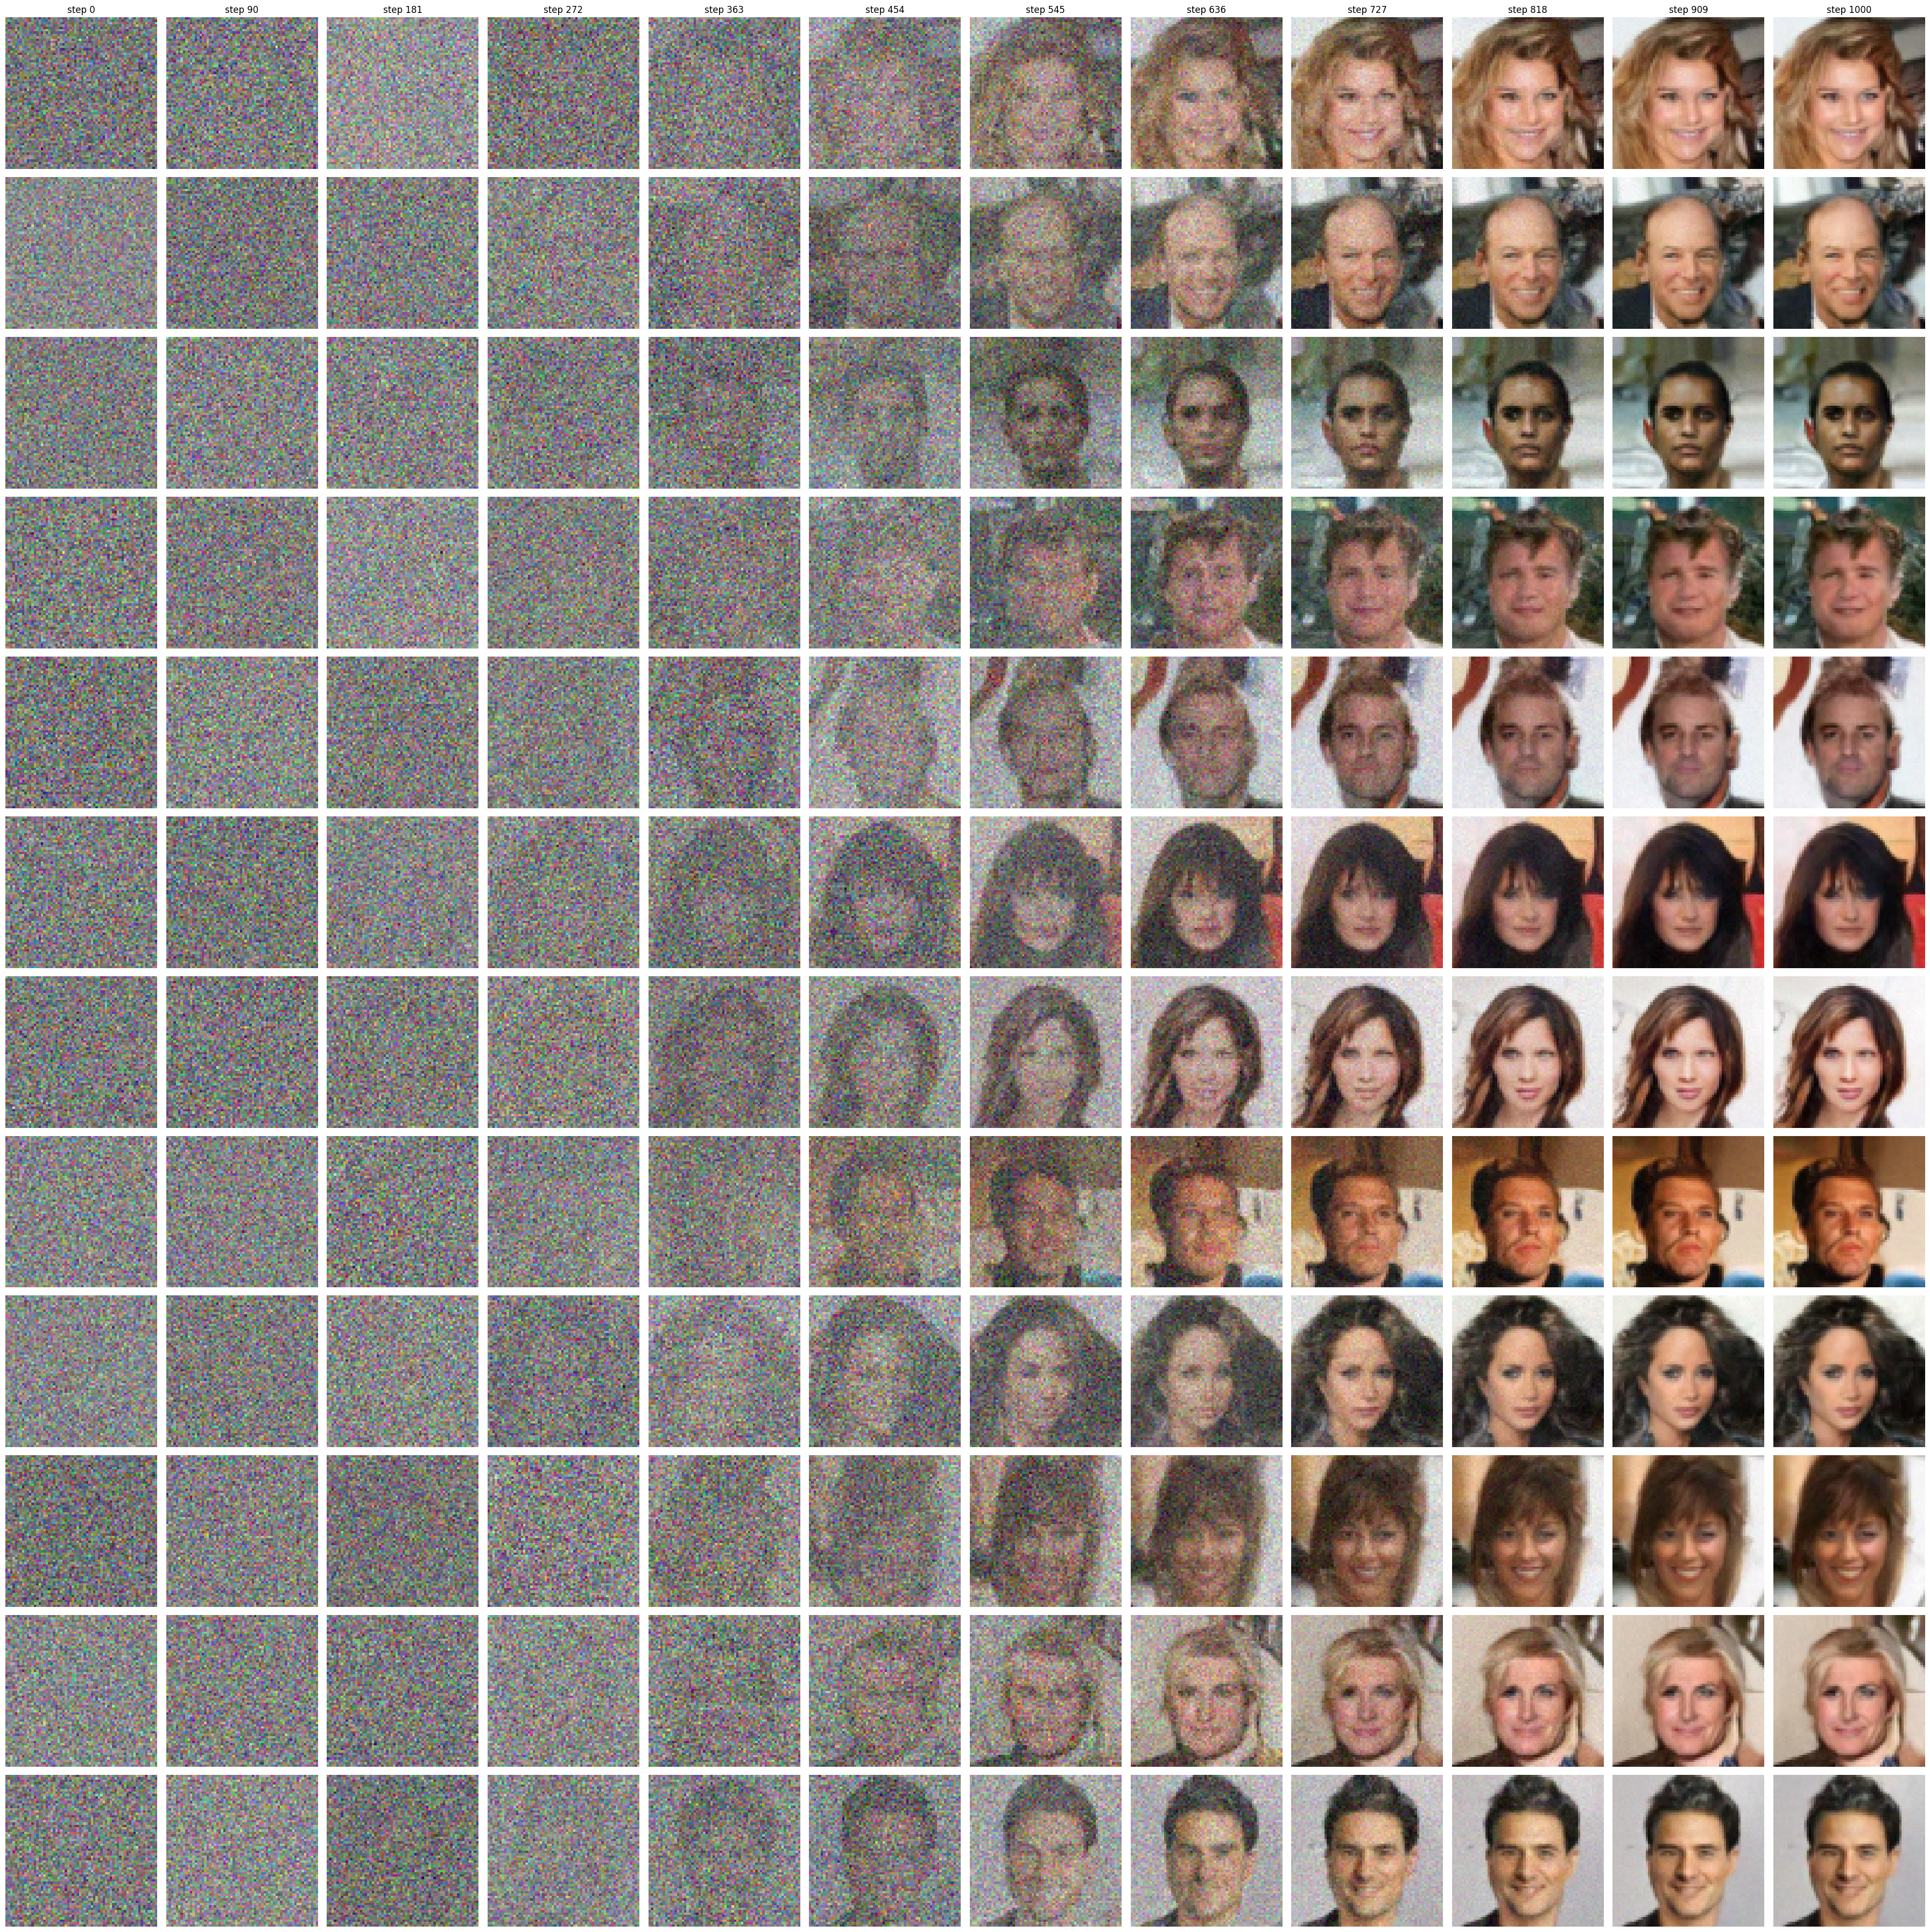

In [15]:

# afficher l'évolution pour 4 images
plot_pc_snr_evolution(snapshots, n_display=[i for i in range(12)])


In [16]:
# %% [Samplers: PC, P-only, C-only]

@torch.no_grad()
def p_only_sampler_ve(
    num_samples=64,
    num_steps=1000,
    eps=1e-5,
):
    """
    VE-SDE sampler with predictor only (no corrector).
    """
    model.eval()
    B = num_samples
    C = 3
    H = W = img_size

    x = sde.prior_sampling((B, C, H, W), device=device)
    t_grid = torch.linspace(1.0, eps, num_steps + 1, device=device)

    for i in range(num_steps):
        t      = t_grid[i].expand(B)
        t_next = t_grid[i + 1].expand(B)
        dt = (t_next[0] - t[0]).item()   # < 0

        g_t = sde.g(t)                   # (B,)
        sigma_vec   = sde.sigma(t)
        sigma_batch = sigma_vec.view(B, 1)
        score = model(x, sigma_batch)

        drift = -(g_t ** 2).view(B, 1, 1, 1) * score
        noise = torch.randn_like(x)

        x_mean = x + drift * dt
        x = x_mean + noise * torch.sqrt(torch.tensor(-dt, device=device)) \
                    * g_t.view(B, 1, 1, 1)

    return x


@torch.no_grad()
def c_only_sampler_ve_snr(
    num_samples=64,
    num_steps=1000,
    n_corrector_steps=1,
    snr=0.16,
    eps=1e-5,
):
    """
    Corrector-only sampler (no predictor).
    We start from the VE prior and apply only Langevin corrector
    along a decreasing time grid.
    """
    model.eval()
    B = num_samples
    C = 3
    H = W = img_size

    x = sde.prior_sampling((B, C, H, W), device=device)
    t_grid = torch.linspace(1.0, eps, num_steps + 1, device=device)

    for i in range(num_steps):
        t = t_grid[i].expand(B)  # time at which we apply the corrector
        x = langevin_corrector_snr(
            x, t, model,
            snr=snr,
            n_steps=n_corrector_steps
        )

    return x


@torch.no_grad()
def pc_sampler_ve_snr_wrapper(
    num_samples=64,
    num_steps=1000,
    n_corrector_steps=1,
    snr=0.16,
    eps=1e-5,
):
    """
    Wrapper around your existing PC sampler, for clarity.
    """
    x_final, _ = pc_sampler_ve_snr(
        num_samples=num_samples,
        num_steps=num_steps,
        n_corrector_steps=n_corrector_steps,
        snr=snr,
        eps=eps,
        snapshots_every=10,
    )
    return x_final


In [17]:
# %% [Helper to save sample grids]

def save_grid(x, nrow, filename, title=None, cmap='gray'):
    """
    x: (B,C,H,W) on device
    Sauvegarde une grille [0,1] dans SAMPLES_DIR/filename.
    """
    x_vis = per_image_minmax_to_01(x).cpu()
    grid = make_grid(x_vis, nrow=nrow)
    plt.figure(figsize=(nrow * 1.5, 1.5 * (x.shape[0] // nrow)))
    if x.shape[1] == 1:
        plt.imshow(grid.permute(1, 2, 0).squeeze(-1), cmap=cmap)
    else:
        plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    if title is not None:
        plt.title(title)
    out_path = os.path.join(SAMPLES_DIR, filename)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved {out_path}")


In [ ]:
# %% [PC vs C-only vs P-only comparison]

num_samples = 64
num_steps = 1000
n_corrector_steps = 1
snr_ref = 0.16

torch.manual_seed(0)
x_pc = pc_sampler_ve_snr_wrapper(
    num_samples=num_samples,
    num_steps=num_steps,
    n_corrector_steps=n_corrector_steps,
    snr=snr_ref,
)

torch.manual_seed(0)
x_p_only = p_only_sampler_ve(
    num_samples=num_samples,
    num_steps=2*num_steps,
)

torch.manual_seed(0)
x_c_only = c_only_sampler_ve_snr(
    num_samples=num_samples,
    num_steps=2*num_steps,
    n_corrector_steps=n_corrector_steps,
    snr=snr_ref,
)

# save grids
save_grid(
    x_pc,
    nrow=8,
    filename=f"mnist_PC_snr{snr_ref:.2f}_steps{num_steps}.png",
    title=f"PC sampler (snr={snr_ref}, steps={num_steps})",
)

save_grid(
    x_c_only,
    nrow=8,
    filename=f"mnist_C_only_snr{snr_ref:.2f}_steps{2*num_steps}.png",
    title=f"C-only sampler (snr={snr_ref}, steps={2*num_steps})",
)

save_grid(
    x_p_only,
    nrow=8,
    filename=f"mnist_P_only_steps{2*num_steps}.png",
    title=f"P-only sampler (steps={2*num_steps})",
)
